# 00-01 Barcelona vs Real Madrid：怎样进入进攻三区？

**问题：** 两队在这场比赛中通过多少次成功传球或持球推进进入进攻三区？这些进入由谁完成、使用什么传球高度、从哪里开始？

**分析单位：** 一次起点满足 `x < 80`、终点满足 `x >= 80` 的 Pass 或 Carry 事件。

**预期产物：** 一张事件表、两张汇总图和一张球场箭头图。图只能描述这场比赛中的记录，不能单独证明球队的稳定风格或战术原因。

## 学习路径

1. 读取一场比赛的原始 events JSON。
2. 把不同嵌套结构的 Pass 和 Carry 整理成统一的进入事件表。
3. 按球队、方式、传球高度和球员汇总。
4. 在 StatsBomb 球场坐标上画出每次进入。
5. 区分指标结果、足球解释与仍待验证的假设。

In [1]:
from __future__ import annotations

import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D
from mplsoccer import Pitch

from football_analytics import get_open_data_root, get_project_root

MATCH_ID = 3773585
SOURCE_COMMIT = "b0bc9f22dd77c206ddedc1d742893b3bbe64baec"
PROJECT_ROOT = get_project_root()
OPEN_DATA_ROOT = get_open_data_root(PROJECT_ROOT)
EVENTS_PATH = OPEN_DATA_ROOT / "data" / "events" / f"{MATCH_ID}.json"

with EVENTS_PATH.open() as handle:
    events = json.load(handle)

len(events), EVENTS_PATH.relative_to(PROJECT_ROOT), SOURCE_COMMIT

(4213,
 PosixPath('data/external/statsbomb-open-data/data/events/3773585.json'),
 'b0bc9f22dd77c206ddedc1d742893b3bbe64baec')

## 1. 建立进入事件表

`Pass` 的终点位于 `pass.end_location`，`Carry` 的终点位于 `carry.end_location`。StatsBomb 的 `Dribble` 表示一次过人尝试，不提供这类持续移动的终点，因此这里使用 Carry 表示持球推进。

成功传球没有 `pass.outcome` 字段。我们保留 `play_pattern` 和 `pass_type`，以便之后区分常规进攻、界外球和定位球来源。

In [2]:
entry_rows: list[dict[str, object]] = []

for event in events:
    method = event["type"]["name"]
    start = event.get("location")
    if method not in {"Pass", "Carry"} or start is None:
        continue

    detail = event[method.lower()]
    end = detail.get("end_location")
    if end is None or not start[0] < 80 <= end[0]:
        continue
    if method == "Pass" and detail.get("outcome") is not None:
        continue

    entry_rows.append(
        {
            "event_id": event["id"],
            "minute": event["minute"],
            "team": event["team"]["name"],
            "player": event.get("player", {}).get("name"),
            "method": method,
            "play_pattern": event["play_pattern"]["name"],
            "pass_type": detail.get("type", {}).get("name") if method == "Pass" else None,
            "pass_height": detail.get("height", {}).get("name") if method == "Pass" else None,
            "length": detail.get("length", math.dist(start, end)),
            "start_x": start[0],
            "start_y": start[1],
            "end_x": end[0],
            "end_y": end[1],
        }
    )

entries = pd.DataFrame(entry_rows)
entries.head(8)

,event_id,minute,team,player,method,play_pattern,pass_type,pass_height,length,start_x,start_y,end_x,end_y
0,31509e6a-d5b1-4a94-a47b-c77d9492c1c4,2,Barcelona,Lionel Andrés Messi Cuccittini,Pass,Regular Play,NaN,Low Pass,32.088783,70.5,51.1,91.8,75.1
1,84b89d6a-8952-4d07-93e0-881f462e0ec1,3,Barcelona,Lionel Andrés Messi Cuccittini,Carry,Regular Play,NaN,NaN,4.716991,76.5,40.9,80.5,38.4
2,07c22583-e3ac-473d-ba43-89e923e4b55b,3,Real Madrid,Carlos Henrique Casimiro,Pass,From Keeper,NaN,High Pass,48.325665,44.1,45.9,83.2,17.5
3,74e2e017-da8e-4c91-ba74-e1e58e4fa39a,4,Real Madrid,Karim Benzema,Carry,From Keeper,NaN,NaN,16.348700,69.0,67.8,84.8,63.6
4,ee6e8929-5336-40cb-8321-b59a3eaab9b8,6,Real Madrid,Karim Benzema,Carry,Regular Play,NaN,NaN,20.412006,72.7,14.7,93.1,15.4
5,a26559f0-d5f9-474c-be25-c2ad857a6776,6,Real Madrid,Raphaël Varane,Pass,Regular Play,NaN,High Pass,53.976753,57.8,47.1,94.8,7.8
6,cb049c3e-6595-47fd-9b72-c86fc32b9361,7,Barcelona,Lionel Andrés Messi Cuccittini,Pass,From Free Kick,NaN,High Pass,46.536976,68.6,9.3,112.3,25.3
7,a667bd52-cbc8-4ca4-96d5-306adb14339d,9,Barcelona,Sergio Busquets i Burgos,Pass,Regular Play,NaN,Ground Pass,15.061541,69.3,29.8,83.2,35.6


In [3]:
assert len(entries) == 117
assert set(entries["method"]) == {"Pass", "Carry"}
assert entries["event_id"].is_unique
assert entries["start_x"].lt(80).all()
assert entries["end_x"].ge(80).all()

pd.Series(
    {
        "source_events": len(events),
        "final_third_entries": len(entries),
        "teams": entries["team"].nunique(),
        "players": entries["player"].nunique(),
    },
    name="data fact",
).to_frame()

,data fact
source_events,4213
final_third_entries,117
teams,2
players,24


上面的断言检查了本课定义，而不是验证比赛表现：每行必须是唯一事件、起点在三区外、终点在三区内。

In [4]:
method_counts = (
    pd.crosstab(entries["team"], entries["method"])
    .reindex(columns=["Pass", "Carry"], fill_value=0)
)
method_counts["Total"] = method_counts.sum(axis=1)

pass_entries = entries.loc[entries["method"] == "Pass"].copy()
height_order = ["Ground Pass", "Low Pass", "High Pass"]
height_counts = (
    pd.crosstab(pass_entries["team"], pass_entries["pass_height"])
    .reindex(columns=height_order, fill_value=0)
)
pass_length_summary = pass_entries.groupby("team")["length"].agg(
    count="size", median="median", mean="mean"
).round(2)

method_counts, height_counts, pass_length_summary

(method       Pass  Carry  Total
 team                           
 Barcelona      40     23     63
 Real Madrid    34     20     54,
 pass_height  Ground Pass  Low Pass  High Pass
 team                                         
 Barcelona             33         5          2
 Real Madrid           22         2         10,
              count  median   mean
 team                             
 Barcelona       40   19.28  22.38
 Real Madrid     34   21.00  26.38)

## 2. 球队层面的方式与高度

左图比较进入次数和方式；右图只看成功传球，并拆分 Ground、Low、High。原始数量会受到控球和比赛状态影响，因此这里先描述，不直接称为球队风格。

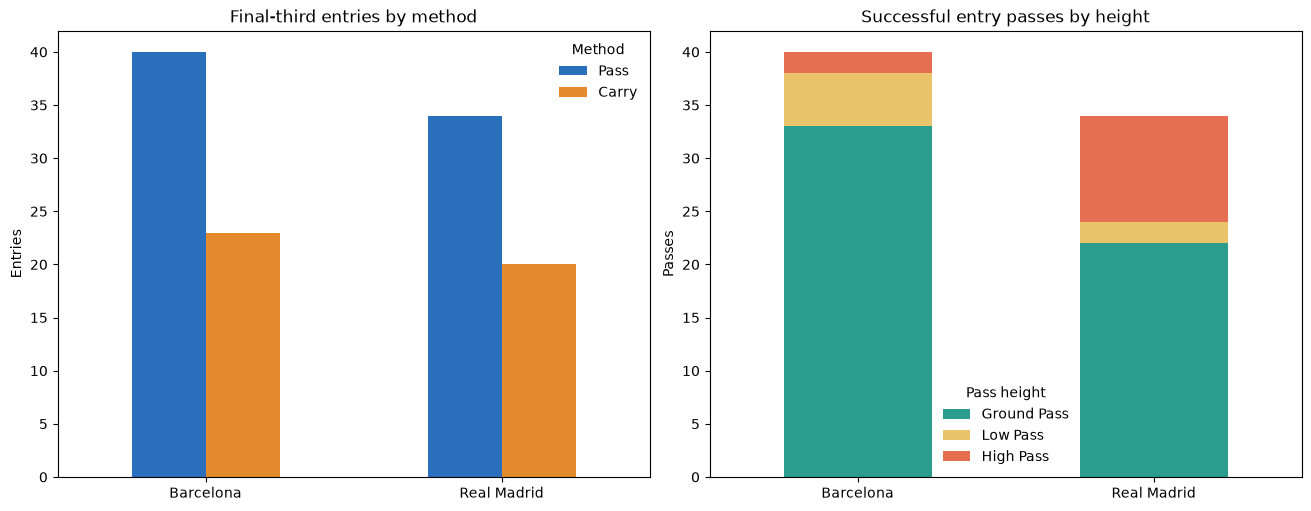

In [5]:
team_order = ["Barcelona", "Real Madrid"]
method_colors = {"Pass": "#2A6FBB", "Carry": "#E38B2C"}
height_colors = {
    "Ground Pass": "#2A9D8F",
    "Low Pass": "#E9C46A",
    "High Pass": "#E76F51",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
method_counts.loc[team_order, ["Pass", "Carry"]].plot.bar(
    ax=axes[0], color=[method_colors["Pass"], method_colors["Carry"]], rot=0
)
axes[0].set(title="Final-third entries by method", xlabel="", ylabel="Entries")
axes[0].legend(title="Method", frameon=False)

height_counts.loc[team_order, height_order].plot.bar(
    ax=axes[1], stacked=True, color=[height_colors[name] for name in height_order], rot=0
)
axes[1].set(title="Successful entry passes by height", xlabel="", ylabel="Passes")
axes[1].legend(title="Pass height", frameon=False)
plt.show()

## 3. 哪些球员完成进入？

每队选取进入次数最多的五名球员，并在同一条形中拆分 Pass 和 Carry。这里衡量的是这场比赛中的事件贡献，不等同于球员能力。

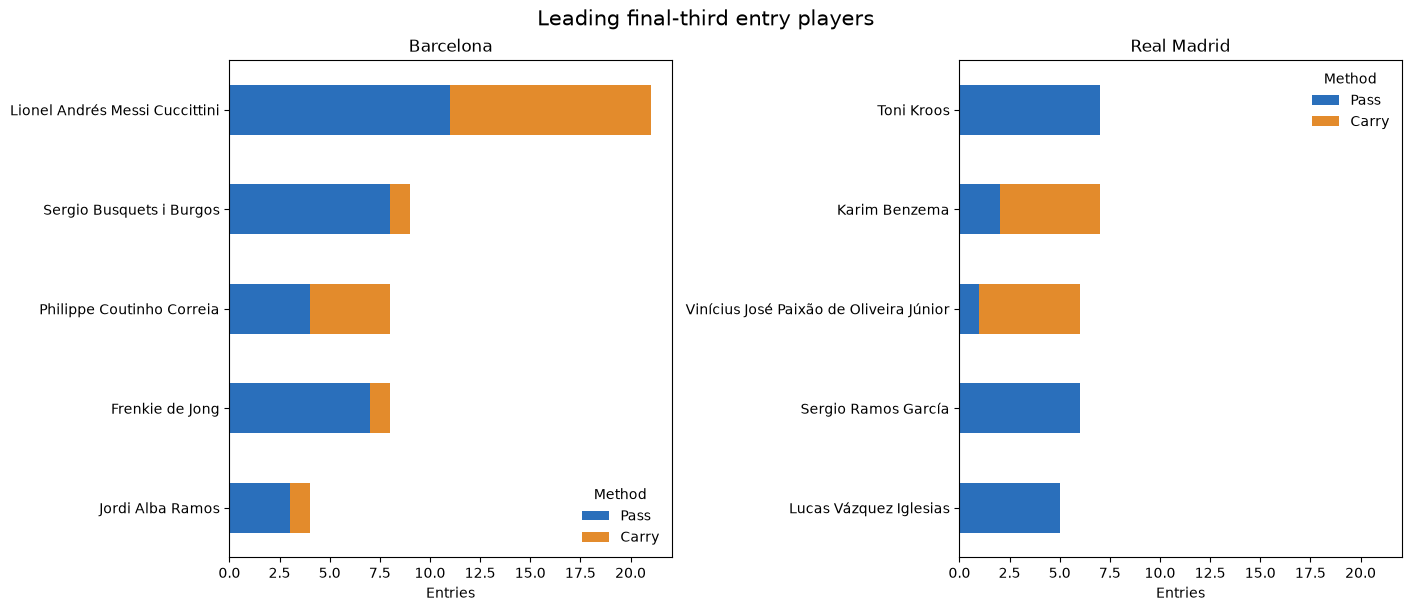

In [6]:
player_method = (
    entries.groupby(["team", "player", "method"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["Pass", "Carry"], fill_value=0)
)
player_method["Total"] = player_method.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True, sharex=True)
for ax, team in zip(axes, team_order, strict=True):
    top = player_method.loc[team].nlargest(5, "Total").sort_values("Total")
    top[["Pass", "Carry"]].plot.barh(
        ax=ax, stacked=True, color=[method_colors["Pass"], method_colors["Carry"]]
    )
    ax.set(title=team, xlabel="Entries", ylabel="")
    ax.legend(title="Method", frameon=False)
fig.suptitle("Leading final-third entry players", fontsize=15)
plt.show()

## 4. 进入发生在哪里？

箭头起点在 `x < 80`，终点在阴影表示的进攻三区。颜色表示 Pass 或 Carry。大量重叠本身也是信息：下一步可以按路线、比赛时间或进攻来源继续拆分，而不是只美化图形。

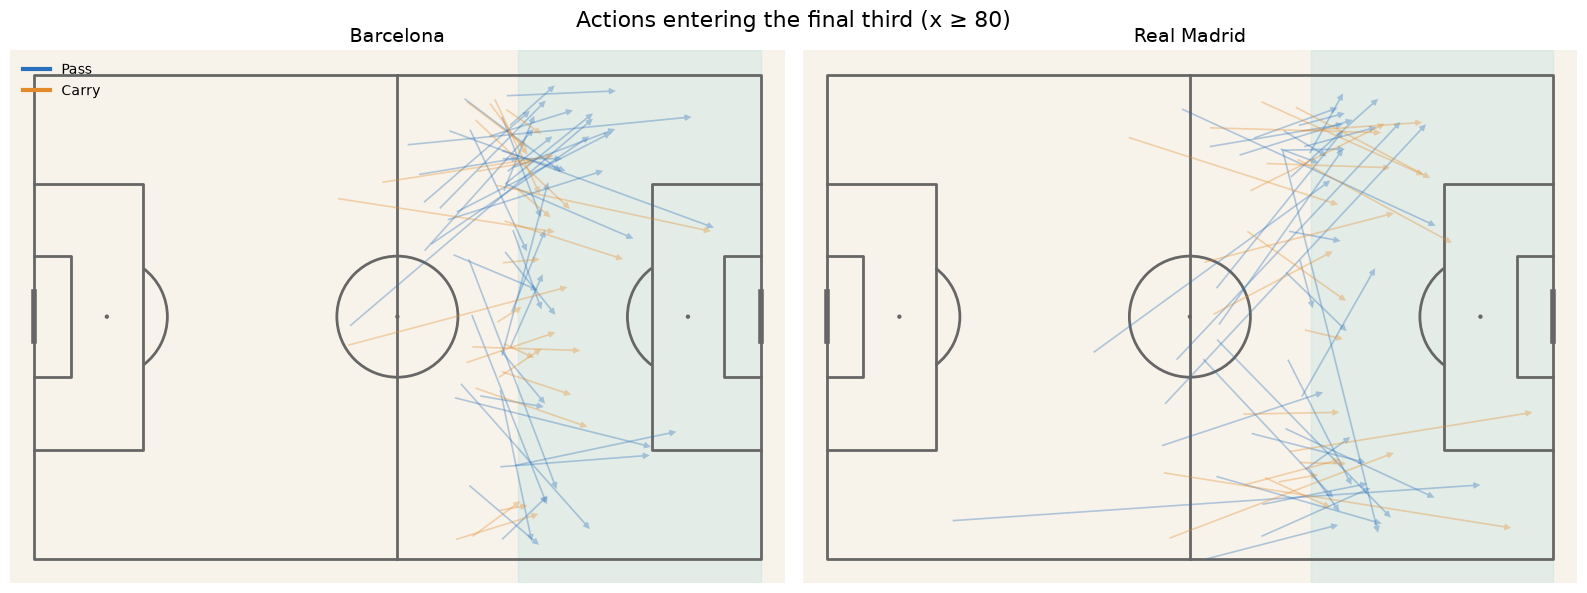

In [7]:
pitch = Pitch(pitch_type="statsbomb", pitch_color="#F7F3EA", line_color="#666666")
fig, axes = pitch.draw(ncols=2, figsize=(16, 6), constrained_layout=True)

for ax, team in zip(axes, team_order, strict=True):
    ax.axvspan(80, 120, color="#A8DADC", alpha=0.25, zorder=0)
    for method in ["Pass", "Carry"]:
        subset = entries.loc[(entries["team"] == team) & (entries["method"] == method)]
        pitch.arrows(
            subset["start_x"], subset["start_y"], subset["end_x"], subset["end_y"],
            ax=ax, color=method_colors[method], alpha=0.35,
            width=1.2, headwidth=4, headlength=4,
        )
    ax.set_title(team, fontsize=14)

legend = [
    Line2D([0], [0], color=method_colors["Pass"], lw=3, label="Pass"),
    Line2D([0], [0], color=method_colors["Carry"], lw=3, label="Carry"),
]
axes[0].legend(handles=legend, loc="upper left", frameon=False)
fig.suptitle("Actions entering the final third (x ≥ 80)", fontsize=16)
plt.show()

## 当前读法与证据边界

- **数据事实：** 原始文件包含 4,213 个 events；本课定义筛出 117 次进入。
- **指标结果：** Barcelona 记录到 63 次进入，Real Madrid 54 次；两队 Pass/Carry 比例接近，但成功进入传球的高度分布不同。
- **足球解释：** 这些图描述本场进入三区的方式、参与者和空间路线。
- **未验证假设：** 高空进入差异是否代表稳定的直接性或战术选择，需要更多比赛、失败尝试、比赛状态和视频支持。

此外，当前结果包含不同 `play_pattern`。直接界外球是 `pass_type=Throw-in`，而界外球发起的后续进攻是 `play_pattern=From Throw In`；二者不能混为一谈。

## 练习

把 `entries` 限制为 `play_pattern == "Regular Play"`，重新生成球队汇总。比较结果后回答：原图中有多少差异来自定位球或界外球发起的进攻？

In [8]:
regular_play_entries = entries.loc[entries["play_pattern"] == "Regular Play"]
pd.crosstab(regular_play_entries["team"], regular_play_entries["method"]).reindex(
    columns=["Pass", "Carry"], fill_value=0
)

method,Pass,Carry
team,,
Barcelona,19,13
Real Madrid,18,13
